In [1]:
import matplotlib.pyplot as plt
import astricaltools as at
import numpy as np
import pandas as pd
import scipy.stats as sc
from astropy import stats
import astropy.units as u
from astropy.io import fits
from astropy.table import vstack, Table
from astropy.time import Time
from astropy.timeseries import TimeSeries
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, Angle

In [2]:
file_numbers = range(1, 10)  # da 001 a 009
base_path = "astri_{:03d}_43_009_00002_R_201023_004_0201_SEB.lv0"  # pattern del nome file

dfs = []  # lista per accumulare i DataFrame
print("\n")
for i in file_numbers:
    filename = base_path.format(i)
    print(f"{filename}")

    with at.io.fits.AstriFits(filename) as hdul:
        data = hdul[1].data

        # Conversione dei campi
        time_ns = data["TIME_NS"].byteswap().newbyteorder().astype(np.int64)
        time_s  = data["TIME_S"].byteswap().newbyteorder().astype(np.int64)
        event   = data["EVTNUM"].byteswap().newbyteorder().astype(np.int64)
        mcrun   = data["MCRUNNUM"].byteswap().newbyteorder().astype(np.int64)
        ntel= data["NTRIGTEL"]
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
        hg, lg, ttp = hdul.get_data('events', ['hi', 'lo', 'ttp'])
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
            #creo il dataframe
        df = pd.DataFrame({
                "TIME_NS": time_ns,
                "TIME_S": time_s,
                "TIME_ABS": time_abs,
                "EVENT": event,
                "MCRUN": mcrun,
                "TEL_ID": i,
                "num_tel": ntel,
                "HG": list(hg),             
                "LG": list(lg),
                "TTP": list(ttp),
            })

        dfs.append(df)
df_all = pd.concat(dfs, ignore_index=True)
df_all_sorted= df_all.sort_values(by="TIME_ABS").reset_index(drop=True)
df_all_sorted["shape"] = df_all_sorted["HG"].apply(np.sum).to_numpy()
df
#print(df_all_sorted.head())
#print(len(df_all_sorted))




astri_001_43_009_00002_R_201023_004_0201_SEB.lv0
astri_002_43_009_00002_R_201023_004_0201_SEB.lv0
astri_003_43_009_00002_R_201023_004_0201_SEB.lv0
astri_004_43_009_00002_R_201023_004_0201_SEB.lv0
astri_005_43_009_00002_R_201023_004_0201_SEB.lv0
astri_006_43_009_00002_R_201023_004_0201_SEB.lv0
astri_007_43_009_00002_R_201023_004_0201_SEB.lv0
astri_008_43_009_00002_R_201023_004_0201_SEB.lv0
astri_009_43_009_00002_R_201023_004_0201_SEB.lv0


,TIME_NS,TIME_S,TIME_ABS,EVENT,MCRUN,TEL_ID,num_tel,HG,LG,TTP
0,1030456,0,1030456,3519,263210,9,2,"[[2126, 2121, 2134, 2208, 2194, 2174, 2226, 22...","[[2128, 2128, 2129, 2132, 2132, 2130, 2133, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."
1,3274338,0,3274338,3803,263210,9,1,"[[2110, 2200, 2063, 2231, 2197, 2243, 2190, 20...","[[2127, 2132, 2125, 2133, 2132, 2134, 2131, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."
2,3679960,0,3679960,3805,263210,9,8,"[[2109, 2063, 2115, 2171, 2186, 2107, 2261, 22...","[[2127, 2125, 2128, 2130, 2131, 2127, 2134, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."
3,6391145,0,6391145,1011,263211,9,1,"[[2085, 2210, 2268, 2181, 2261, 2070, 2185, 21...","[[2126, 2132, 2135, 2131, 2135, 2125, 2131, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."
4,10916501,0,10916501,1209,263211,9,1,"[[2126, 2191, 2261, 2007, 2195, 2182, 2129, 22...","[[2128, 2131, 2135, 2122, 2131, 2131, 2128, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 123,..."
...,...,...,...,...,...,...,...,...,...,...
3157,316424396,9,9316424396,7915,266398,9,8,"[[2152, 2187, 2166, 2148, 2147, 2127, 2174, 21...","[[2129, 2131, 2130, 2129, 2129, 2128, 2130, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."
3158,321000985,9,9321000985,8402,266398,9,9,"[[2113, 2050, 2263, 2073, 2132, 2078, 2293, 20...","[[2127, 2124, 2135, 2125, 2128, 2126, 2136, 21...","[[255, 255, 255, 158, 255, 255, 255, 255, 255,..."
3159,326043880,9,9326043880,1403,266399,9,9,"[[2385, 2234, 2198, 2229, 2154, 2125, 2167, 21...","[[2141, 2133, 2132, 2133, 2129, 2128, 2130, 21...","[[117, 255, 255, 255, 255, 255, 255, 255, 255,..."
3160,329345615,9,9329345615,2419,266399,9,6,"[[2147, 2090, 2225, 2220, 2201, 2126, 2132, 22...","[[2129, 2126, 2133, 2133, 2132, 2128, 2128, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."


In [3]:
def principal_axis(cov):
            l1 = (cov[0,0] + cov[1,1])/2 + np.sqrt(
                ((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)
            theta = np.arctan2(l1 - cov[0,0], cov[0,1])
            return l1, theta
#raccolgo i dati delle rette divisi per ogni (event,mcrun)
df_all_sorted=df_all_sorted[df_all_sorted["shape"]>5.16e6]
df_all_sorted=df_all_sorted[df_all_sorted["num_tel"]>=3]

print(len(df_all_sorted))

xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

#rette_hg=[]
#rette_lg=[]
results = []

for (event, mcrun), df_evt in df_all_sorted.groupby(["EVENT", "MCRUN"]):

    for iv, row in df_evt.iterrows():

        itel = row["TEL_ID"]
        hgev = np.array(row["HG"])
        lgev = np.array(row["LG"])
        ttpev = np.array(row["TTP"])

        # filtro temporale
        pxmask = (hgev > 2400) & (ttpev < 255)
        if  np.sum(pxmask) == 0:
            continue
        # SIGMA-CLIPPING
    
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()

        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)

        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)

        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)

        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]
        # ---------- centroidi ----------
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)

        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)

        # ---------- covarianze ----------
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)
        # autovalori + direzione
        

        l1_hg, theta_hg = principal_axis(cov_hg)
        l1_lg, theta_lg = principal_axis(cov_lg)

        results.append({
            "event": event,
            "mcrun": mcrun,
            "HG": {
                "p0": np.array([meanx_hg, meany_hg]),
                "d":  np.array([np.cos(theta_hg), np.sin(theta_hg)]),
                "l1": l1_hg,
                "tel": itel
            },
            "LG": {
                "p0": np.array([meanx_lg, meany_lg]),
                "d":  np.array([np.cos(theta_lg), np.sin(theta_lg)]),
                "l1": l1_lg,
                "tel": itel
            }
        })


4213


In [4]:
# ======================= FUNZIONI GEOMETRICHE =======================

def intersection(p1, d1, p2, d2, eps_ang=1e-3, eps_det=1e-6):
    """
    p1, p2 = punti (2,)
    d1, d2 = direzioni (2,)
    """

    # --- controllo quasi-parallelismo (UNICO, definitivo) ---
    det_dir = d1[0]*d2[1] - d1[1]*d2[0]
    if abs(det_dir) < eps_ang:        # <<< taglio fisico
        return None

    A = np.array([d1, -d2]).T
    b = p2 - p1

    detA = np.linalg.det(A)
    if abs(detA) < eps_det:           # <<< sicurezza numerica
        return None

    t = np.linalg.solve(A, b)[0]
    return p1 + t * d1
def d_punto_retta(P, p0, d):
    norm_d = np.linalg.norm(d)
    if norm_d == 0:
        return np.nan
    d_unit = d / norm_d
    v = P - p0
    return abs(v[0] * d_unit[1] - v[1] * d_unit[0])
def d_punto_retta_vec(P, p0, d):
    """
    distanza di N rette da un punto
    """
    norm_d = np.linalg.norm(d, axis=1)
    mask = norm_d > 0
    d_unit = np.zeros_like(d)
    d_unit[mask] = d[mask] / norm_d[mask, None]
    v = P - p0
    return np.abs(v[:, 0] * d_unit[:, 1] - v[:, 1] * d_unit[:, 0])


In [5]:
# ======================= CALCOLO INTERSEZIONI =======================
inters_hg = []
inters_lg = []
dfR = pd.DataFrame(results)
for (event, mcrun), df_evt in dfR.groupby(["event", "mcrun"]):

    rette_hg = df_evt["HG"].values
    rette_lg = df_evt["LG"].values

    # ---------- HG ----------
    for i in range(len(rette_hg)):
        for j in range(i+1, len(rette_hg)):

            if rette_hg[i]["tel"] == rette_hg[j]["tel"]:
                continue

            d1 = rette_hg[i]["d"]
            d2 = rette_hg[j]["d"]

            P = intersection(
                rette_hg[i]["p0"], d1,
                rette_hg[j]["p0"], d2
            )

            if P is None:
                continue

            inters_hg.append({
                "event": event,
                "mcrun": mcrun,
                "P": P,
                "pair": (i, j)
            })

    # ---------- LG ----------
    for i in range(len(rette_lg)):
        for j in range(i+1, len(rette_lg)):

            if rette_lg[i]["tel"] == rette_lg[j]["tel"]:
                continue

            d1 = rette_lg[i]["d"]
            d2 = rette_lg[j]["d"]

            P = intersection(
                rette_lg[i]["p0"], d1,
                rette_lg[j]["p0"], d2
            )

            if P is None:
                continue

            inters_lg.append({
                "event": event,
                "mcrun": mcrun,
                "P": P,
                "pair": (i, j)
            })

df_int_hg = pd.DataFrame(inters_hg)
df_int_lg = pd.DataFrame(inters_lg)


In [25]:
from sklearn.cluster import DBSCAN

epsilon = 200
min_samples = 1
revent_map = {}
revent_counter = 0
# ======================= HG =======================
dist_hg = []
delta_hg = []

for (event, mcrun), df_evt in df_int_hg.groupby(["event", "mcrun"]):
    # -------- REVENT --------
    if (event, mcrun) not in revent_map:
        revent_map[(event, mcrun)] = revent_counter
        revent_counter += 1
    revent = revent_map[(event, mcrun)]
    # ------------------------
    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    dfR_evt = dfR.loc[
        (dfR["event"] == event) & (dfR["mcrun"] == mcrun),
        "HG"
    ]

    p0  = np.array([r["p0"]  for r in dfR_evt])
    d   = np.array([r["d"]   for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])

    for lab in cl_labels:

        mask = labels == lab
        Pcl  = P[mask]
        dfP  = df_evt.loc[mask]

        # ---------- pesi angolari (VETTORIALI) ----------
        pairs = np.array(dfP["pair"].tolist())      # (N,2)
        d1 = d[pairs[:, 0]]
        d2 = d[pairs[:, 1]]

        w = (d1[:, 0]*d2[:, 1] - d1[:, 1]*d2[:, 0])**2   # sin^2(theta)

        # ---------- stimatori ----------
        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)

        # ---------- diagnostica ----------
        delta_hg.append(np.linalg.norm(P_weight - P_simple))

        # ---------- distanze ----------
        dist_w = d_punto_retta_vec(P_weight, p0, d)
        dist_m = d_punto_retta_vec(P_median, p0, d)
        dist_s = d_punto_retta_vec(P_simple, p0, d)
        for t, ds, dw, dm in zip(tel, dist_s, dist_w, dist_m):
            dist_hg.append({
                "revent": revent, 
                "event": event,
                "mcrun": mcrun,
                "cluster": lab,
                "tel": t,
                "P_simple": P_simple.copy(),
                "P_weight": P_weight.copy(),
                "P_median": P_median.copy(),
                "d_simple": ds,
                "d_weight": dw,
                "d_median": dm
            })
                

df_dist_hg = pd.DataFrame(dist_hg)


# ======================= LG =======================
dist_lg = []
delta_lg = []

for (event, mcrun), df_evt in df_int_lg.groupby(["event", "mcrun"]):
    # -------- REVENT --------
    if (event, mcrun) not in revent_map:
        revent_map[(event, mcrun)] = revent_counter
        revent_counter += 1
    revent = revent_map[(event, mcrun)]
    # ------------------------
    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    dfR_evt = dfR.loc[
        (dfR["event"] == event) & (dfR["mcrun"] == mcrun),
        "LG"
    ]

    p0  = np.array([r["p0"]  for r in dfR_evt])
    d   = np.array([r["d"]   for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])

    for lab in cl_labels:

        mask = labels == lab
        Pcl  = P[mask]
        dfP  = df_evt.loc[mask]

        pairs = np.array(dfP["pair"].tolist())
        d1 = d[pairs[:, 0]]
        d2 = d[pairs[:, 1]]

        w = (d1[:, 0]*d2[:, 1] - d1[:, 1]*d2[:, 0])**2

        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)

        delta_lg.append(np.linalg.norm(P_weight - P_simple))

        dist_w = d_punto_retta_vec(P_weight, p0, d)
        dist_m = d_punto_retta_vec(P_median, p0, d)
        dist_s = d_punto_retta_vec(P_simple, p0, d)
        for t, ds, dw, dm in zip(tel, dist_s, dist_w, dist_m):
            dist_lg.append({
                "revent": revent,
                "event": event,
                "mcrun": mcrun,
                "cluster": lab,
                "tel": t,
                "P_simple": P_simple.copy(),
                "P_weight": P_weight.copy(),
                "P_median": P_median.copy(),
                "d_simple": ds,
                "d_weight": dw,
                "d_median": dm
            })

df_dist_lg = pd.DataFrame(dist_lg)


In [26]:
#=========================== FAKE EVENT ==================================
import random
#vediamo due eventi presi casualmente
groups = list(df_all_sorted.groupby(["EVENT", "MCRUN"]))
random.shuffle(groups)
groups_A = groups[:len(groups)//2]
groups_B = groups[len(groups)//2:len(groups)]
fake_events = []

for i, ((evtA, dfA), (evtB, dfB)) in enumerate(zip(groups_A, groups_B)):
    if len(dfA) < 3 or len(dfB) < 3:
        continue

    #prendi almeno 3 telescopi da A e non più di quelli disponibili
    nA = max(3, len(dfA) // 2)
    nA = min(nA, len(dfA))
    partA = dfA.sample(n=nA, replace=False)

    #prendi almeno 3 telescopi da B e non più di quelli disponibili
    nB = max(3, len(dfB) // 2)
    nB = min(nB, len(dfB))
    partB = dfB.sample(n=nB, replace=False)

    # unione -> evento fittizio
    df_fake = pd.concat([partA, partB], ignore_index=True)
  
    # etichetta evento fittizio
    df_fake["FAKE_EVENT"] = i
    
    fake_events.append(df_fake)
#dataframe con tutti eventi fittizi
df_fake_all = pd.concat(fake_events, ignore_index=True)
df_fake_all.columns


Index(['TIME_NS', 'TIME_S', 'TIME_ABS', 'EVENT', 'MCRUN', 'TEL_ID', 'num_tel',
       'HG', 'LG', 'TTP', 'shape', 'FAKE_EVENT'],
      dtype='object')

In [27]:
#########ora stessa analisi di sopra
xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

#rette_hg=[]
#rette_lg=[]
results_f = []
for fevent, df_evt in df_fake_all.groupby(["FAKE_EVENT"]):

    for iv, row in df_evt.iterrows():

        itel = row["TEL_ID"]
        hgev = np.array(row["HG"])
        lgev = np.array(row["LG"])
        ttpev = np.array(row["TTP"])

        # filtro temporale
        pxmask = (hgev > 2400) & (ttpev < 255)
        if  np.sum(pxmask) == 0:
            continue
        # SIGMA-CLIPPING
    
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()

        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)

        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)

        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)

        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]
        # ---------- centroidi ----------
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)

        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)

        # ---------- covarianze ----------
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)
        # autovalori + direzione
        def principal_axis(cov):
            l1 = (cov[0,0] + cov[1,1])/2 + np.sqrt(
                ((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)
            theta = np.arctan2(l1 - cov[0,0], cov[0,1])
            return l1, theta

        l1_hg, theta_hg = principal_axis(cov_hg)
        l1_lg, theta_lg = principal_axis(cov_lg)

        results_f.append({
            "r_event": np.array([row["MCRUN"],row["EVENT"]]),
            "fevent": fevent,   
            "HG": {
                "p0": np.array([meanx_hg, meany_hg]),
                "d":  np.array([np.cos(theta_hg), np.sin(theta_hg)]),
                "l1": l1_hg,
                "tel": itel
            },
            "LG": {
                "p0": np.array([meanx_lg, meany_lg]),
                "d":  np.array([np.cos(theta_lg), np.sin(theta_lg)]),
                "l1": l1_lg,
                "tel": itel
            }
        })
# ======================= CALCOLO INTERSEZIONI =======================

inters_hg_f = []
inters_lg_f = []

dfR_f = pd.DataFrame(results_f)  # il dataframe con fevent, HG, LG

for fevent, df_evt in dfR_f.groupby("fevent"):   # <<< raggruppo per fevent

    rette_hg = df_evt["HG"].values
    rette_lg = df_evt["LG"].values

    # ---------- HG ----------
    for i in range(len(rette_hg)):
        for j in range(i+1, len(rette_hg)):

            if rette_hg[i]["tel"] == rette_hg[j]["tel"]:
                continue

            d1 = rette_hg[i]["d"]
            d2 = rette_hg[j]["d"]

            # --- ignora rette quasi parallele ---
            if abs(d1[0]*d2[1] - d1[1]*d2[0]) < 1e-3:
                continue

            P = intersection(
                rette_hg[i]["p0"], d1,
                rette_hg[j]["p0"], d2
            )

            if P is None:
                continue

            inters_hg_f.append({
                "fevent": fevent,
                "P": P,
                "pair": (i, j)
            })

    # ---------- LG ----------
    for i in range(len(rette_lg)):
        for j in range(i+1, len(rette_lg)):

            if rette_lg[i]["tel"] == rette_lg[j]["tel"]:
                continue

            d1 = rette_lg[i]["d"]
            d2 = rette_lg[j]["d"]

            # --- ignora rette quasi parallele ---
            if abs(d1[0]*d2[1] - d1[1]*d2[0]) < 1e-3:
                continue

            P = intersection(
                rette_lg[i]["p0"], d1,
                rette_lg[j]["p0"], d2
            )

            if P is None:
                continue

            inters_lg_f.append({
                "fevent": fevent,
                "P": P,
                "pair": (i, j)
            })

# dataframe finali
df_int_hg_f = pd.DataFrame(inters_hg_f)
df_int_lg_f = pd.DataFrame(inters_lg_f)


In [28]:

epsilon = 200
min_samples = 1

# ======================= HG =======================
dist_hg_f = []

for fevent, df_evt in df_int_hg_f.groupby("fevent"):

    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    # clustering DBSCAN
    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    # rette dell'evento falso
    dfR_evt = dfR_f.loc[dfR_f["fevent"] == fevent, "HG"]

    p0  = np.array([r["p0"] for r in dfR_evt])
    d   = np.array([r["d"]  for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])

    # ciclo cluster
    for lab in cl_labels:
        Pcl = P[labels == lab]
        dfP = df_evt[labels == lab]

        # ---------- calcolo pesi angolari ----------
        w = []
        for _, row in dfP.iterrows():
            i, j = row["pair"]          # assumendo che ci sia ancora la colonna "pair"
            d1 = dfR_evt.iloc[i]["d"]
            d2 = dfR_evt.iloc[j]["d"]
            w.append((d1[0]*d2[1] - d1[1]*d2[0])**2)   # sin^2(theta)

        w = np.array(w)

        # ---------- media pesata e semplice ----------
        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)

        dist_mean_simple   = d_punto_retta_vec(P_simple, p0, d)
        dist_mean_weighted = d_punto_retta_vec(P_weight, p0, d)
        dist_median        = d_punto_retta_vec(P_median, p0, d)

        for t, dm_s, dm_w, dmed in zip(tel, dist_mean_simple, dist_mean_weighted, dist_median):
            dist_hg_f.append({
                "fevent": fevent,
                "event" : event,
                "mcrun": mcrun,
                "cluster": lab,
                "tel": t,
                "P_simple": P_simple.copy(),
                "P_weight": P_weight.copy(),
                "P_median": P_median.copy(),
                "d_mean_simple": dm_s,
                "d_mean_weighted": dm_w,
                "d_median": dmed
            })

df_dist_hg_f = pd.DataFrame(dist_hg_f)

# ======================= LG =======================
dist_lg_f = []

for fevent, df_evt in df_int_lg_f.groupby("fevent"):

    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    dfR_evt = dfR_f.loc[dfR_f["fevent"] == fevent, "LG"]

    p0  = np.array([r["p0"] for r in dfR_evt])
    d   = np.array([r["d"]  for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])

    for lab in cl_labels:
        Pcl = P[labels == lab]
        dfP = df_evt[labels == lab]

        # pesi angolari
        w = []
        for _, row in dfP.iterrows():
            i, j = row["pair"]
            d1 = dfR_evt.iloc[i]["d"]
            d2 = dfR_evt.iloc[j]["d"]
            w.append((d1[0]*d2[1] - d1[1]*d2[0])**2)

        w = np.array(w)

        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)

        dist_mean_simple   = d_punto_retta_vec(P_simple, p0, d)
        dist_mean_weighted = d_punto_retta_vec(P_weight, p0, d)
        dist_median        = d_punto_retta_vec(P_median, p0, d)

        for t, dm_s, dm_w, dmed in zip(tel, dist_mean_simple, dist_mean_weighted, dist_median):
            dist_lg_f.append({
                "fevent": fevent,
                "event" : event,
                "mcrun": mcrun,
                "cluster": lab,
                "tel": t,
                "P_simple": P_simple.copy(),
                "P_weight": P_weight.copy(),
                "P_median": P_median.copy(),
                "d_mean_simple": dm_s,
                "d_mean_weighted": dm_w,
                "d_median": dmed
            })

df_dist_lg_f = pd.DataFrame(dist_lg_f)


In [38]:
threshold = 10  # distanza massima per considerare la retta parte del cluster/evento

# ======================= HG =======================
dist_hg_tagged = []

for (event, mcrun), df_evt in df_dist_hg.groupby(["event","mcrun"]):
    # ciclo sui cluster già calcolati
    for cluster_id, df_cl in df_evt.groupby("cluster"):
        # centroide del cluster
        P_mean = df_cl["P_median"].values[0] if "P_median" in df_cl else np.mean(np.vstack(df_cl["P_median"].values), axis=0)

        for idx, row in df_cl.iterrows():
            dm = row["d_weight"]  # distanza già calcolata dal cluster
            tag = "this_event" if dm <= threshold else "other_event"

            dist_hg_tagged.append({
                "revent":row["revent"],
                "event": row["event"],
                "mcrun": row["mcrun"],
                "cluster": row["cluster"],
                "tel": row["tel"],
                "d_weight": row["d_weight"],
                "d_median": row["d_median"],
                "tag": tag,
                "P_median": P_median.copy()
            })

df_dist_hg_tagged = pd.DataFrame(dist_hg_tagged)


# ======================= LG =======================
dist_lg_tagged = []

for (event, mcrun), df_evt in df_dist_lg.groupby(["event","mcrun"]):
    for cluster_id, df_cl in df_evt.groupby("cluster"):
        P_median = df_cl["P_median"].values[0] if "P_median" in df_cl else np.mean(np.vstack(df_cl["P_median"].values), axis=0)

        for idx, row in df_cl.iterrows():
            dm = row["d_weight"]
            tag = "this_event" if dm <= threshold else "other_event"

            dist_lg_tagged.append({
                "revent":row["revent"],
                "event": row["event"],
                "mcrun": row["mcrun"],
                "cluster": row["cluster"],
                "tel": row["tel"],
                "d_weight": row["d_weight"],
                "d_median": row["d_median"],
                "tag": tag,
                "P_mean": P_mean.copy()
            })

df_dist_lg_tagged = pd.DataFrame(dist_lg_tagged)


In [53]:
#===========================prova=============================
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
'''
def evaluate_simple_clustering(df, tag_col="tag"):
    """
    Valuta quanto bene il clustering riconosce gli eventi reali.

    df: DataFrame con colonne:
        - 'event', 'mcrun': etichette reali
        - tag_col: stringa che indica se la retta è assegnata al cluster corretto ('this_event') o no ('other_event')
    
    Ritorna:
        acc, prec, rec, cm
    """
    # y_true = 1 per tutte le rette (appartengono all'evento reale)
    y_true = [1]*len(df)
    # y_pred = 1 se tag = 'this_event', 0 se 'other_event'
    y_pred = df[tag_col].apply(lambda x: 1 if x == "this_event" else 0).values

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print("=== Risultati clustering ===")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")
    print("Matrice di confusione:")
    print(cm)

    return acc, prec, rec, cm
'''

def evaluate_performance(df, tag_col="tag", group_col="revent"):
    N_true = 0
    N_reco = 0
    N_good = 0

    for group_val, df_group in df.groupby(group_col):
        true_events = df_group[["event", "mcrun"]].drop_duplicates()
        N_true += len(true_events)

        # cluster/tag con almeno una retta "this_event"
        active_clusters = df_group[df_group[tag_col] == "this_event"][tag_col].drop_duplicates()
        N_reco += len(active_clusters)

        for cl in active_clusters:
            df_cl = df_group[df_group[tag_col] == "this_event"]
            # eventi veri nel cluster
            events_in_cl = df_cl[["event", "mcrun"]].drop_duplicates()

            if len(events_in_cl) == 1:
                ev, mc = events_in_cl.iloc[0]
                df_true_evt = df_group[(df_group["event"] == ev) & (df_group["mcrun"] == mc)]
                if len(df_cl) == len(df_true_evt):
                    N_good += 1

    efficiency = N_good / N_true if N_true > 0 else 0
    purity = N_good / N_reco if N_reco > 0 else 0

    return {
        "N_true": N_true,
        "N_reco": N_reco,
        "N_good": N_good,
        "efficiency": efficiency,
        "purity": purity
    }

# Esempio di chiamata
res_hg = evaluate_performance(df_dist_hg_tagged, tag_col="tag", group_col="revent")
res_lg = evaluate_performance(df_dist_lg_tagged, tag_col="tag", group_col="revent")

print("=== HG ===")
print(f"N_true: {res_hg['N_true']}")
print(f"N_reco: {res_hg['N_reco']}")
print(f"N_good: {res_hg['N_good']}")
print(f"Efficiency: {res_hg['efficiency']:.3f}")
print(f"Purity: {res_hg['purity']:.3f}")

print("\n=== LG ===")
print(f"N_true: {res_lg['N_true']}")
print(f"N_reco: {res_lg['N_reco']}")
print(f"N_good: {res_lg['N_good']}")
print(f"Efficiency: {res_lg['efficiency']:.3f}")
print(f"Purity: {res_lg['purity']:.3f}")


=== HG ===
N_true: 691
N_reco: 691
N_good: 345
Efficiency: 0.499
Purity: 0.499

=== LG ===
N_true: 692
N_reco: 692
N_good: 319
Efficiency: 0.461
Purity: 0.461


In [50]:
def event_accuracy_by_tag(df):
    total_events = 0
    good_events = 0

    for (event, mcrun), df_evt in df.groupby(["event", "mcrun"]):
        total_events += 1

        # tag unici presenti in questo evento
        unique_tags = df_evt["tag"].unique()

        # evento buono se TUTTE le rette hanno lo stesso tag
        if len(unique_tags) == 1:
            good_events += 1

    accuracy = good_events / total_events if total_events > 0 else 0

    print(f"Eventi totali: {total_events}")
    print(f"Eventi buoni: {good_events}")
    print(f"Accuratezza evento: {accuracy:.3f}")

    return accuracy
event_accuracy_by_tag(df_dist_hg_tagged)


Eventi totali: 691
Eventi buoni: 345
Accuratezza evento: 0.499


0.4992764109985528

In [ ]:
##=============================0 FAKE EVENT ===========================================
dist_hg_tagged = []
for fevent, df_evt in df_dist_hg_f.groupby("fevent"):
    # ciclo sui cluster già calcolati
    for cluster_id, df_cl in df_evt.groupby("cluster"):
        # centroide del cluster
        P_mean = df_cl["P_median"].values[0] if "P_median" in df_cl else np.mean(np.vstack(df_cl["P_median"].values), axis=0)

        for idx, row in df_cl.iterrows():
            dm = row["d_mean_weighted"]  # distanza già calcolata dal cluster
            tag = "this_event" if dm <= threshold else "other_event"

            dist_hg_tagged.append({
                "event": row["event"],
                "mcrun": row["mcrun"],
                "cluster": row["cluster"],
                "tel": row["tel"],
                "d_weight": row["d_mean_weighted"],
                "d_median": row["d_median"],
                "tag": tag,
                "P_median": P_median.copy()
            })

df_dist_hg_tagged_f = pd.DataFrame(dist_hg_tagged)


# ======================= LG =======================
dist_lg_tagged = []

for fevent, df_evt in df_dist_lg_f.groupby("fevent"):
    for cluster_id, df_cl in df_evt.groupby("cluster"):
        P_median = df_cl["P_median"].values[0] if "P_median" in df_cl else np.mean(np.vstack(df_cl["P_median"].values), axis=0)

        for idx, row in df_cl.iterrows():
            dm = row["d_mean_weighted"]
            tag = "this_event" if dm <= threshold else "other_event"

            dist_lg_tagged.append({
                "event": row["event"],
                "mcrun": row["mcrun"],
                "cluster": row["cluster"],
                "tel": row["tel"],
                "d_weight": row["d_mean_weighted"],
                "d_median": row["d_median"],
                "tag": tag,
                "P_mean": P_mean.copy()
            })

df_dist_lg_tagged_f = pd.DataFrame(dist_lg_tagged)

In [ ]:
# HG
acc_hg, prec_hg, rec_hg, cm_hg = evaluate_simple_clustering(df_dist_hg_tagged_f)

# LG
acc_lg, prec_lg, rec_lg, cm_lg = evaluate_simple_clustering(df_dist_lg_tagged_f)

=== Risultati clustering ===
Accuracy:  0.529
Precision: 1.000
Recall:    0.529
Matrice di confusione:
[[   0    0]
 [1897 2127]]
=== Risultati clustering ===
Accuracy:  0.523
Precision: 1.000
Recall:    0.523
Matrice di confusione:
[[   0    0]
 [1938 2127]]


In [ ]:
# ======================== PROVA DI GENERALIZZAZIONE ====================================
#REAL
def build_tagged_df(df_dist, threshold):
    tagged = []

    for (event, mcrun), df_evt in df_dist.groupby(["event", "mcrun"]):

        for cluster_id, df_cl in df_evt.groupby("cluster"):

            for _, row in df_cl.iterrows():

                dm = row["d_weight"]
                tag = "this_event" if dm <= threshold else "other_event"

                tagged.append({
                    "event": event,
                    "mcrun": mcrun,
                    "cluster": cluster_id,
                    "tel": row["tel"],
                    "d_weight": row["d_weight"],
                    "d_median": row["d_median"],
                    "tag": tag
                })

    return pd.DataFrame(tagged)
threshold_values = np.linspace(1, 800, 20)

acc_hg_real = []
acc_lg_real = []

for thr in threshold_values:

    df_hg_tagged = build_tagged_df(df_dist_hg, thr)
    df_lg_tagged = build_tagged_df(df_dist_lg, thr)

    acc_hg_real.append(evaluate_simple_clustering(df_hg_tagged)[0])
    acc_lg_real.append(evaluate_simple_clustering(df_lg_tagged)[0])
#FAKE
def build_tagged_df_fake(df_dist_f, threshold):
    tagged = []

    for fevent, df_evt in df_dist_f.groupby("fevent"):

        for cluster_id, df_cl in df_evt.groupby("cluster"):

            for _, row in df_cl.iterrows():

                dm = row["d_mean_weighted"]
                tag = "this_event" if dm <= threshold else "other_event"

                tagged.append({
                    "event": row["event"],   # ground truth
                    "mcrun": row["mcrun"],   # ground truth
                    "fevent": fevent,
                    "cluster": cluster_id,
                    "tel": row["tel"],
                    "d_weight": row["d_mean_weighted"],
                    "d_median": row["d_median"],
                    "tag": tag
                })

    return pd.DataFrame(tagged)
acc_hg_fake = []
acc_lg_fake = []

for thr in threshold_values:

    df_hg_tagged_f = build_tagged_df_fake(df_dist_hg_f, thr)
    df_lg_tagged_f = build_tagged_df_fake(df_dist_lg_f, thr)

    acc_hg_fake.append(evaluate_simple_clustering(df_hg_tagged_f)[0])
    acc_lg_fake.append(evaluate_simple_clustering(df_lg_tagged_f)[0])


=== Risultati clustering ===
Accuracy:  0.267
Precision: 1.000
Recall:    0.267
Matrice di confusione:
[[   0    0]
 [5149 1871]]
=== Risultati clustering ===
Accuracy:  0.254
Precision: 1.000
Recall:    0.254
Matrice di confusione:
[[   0    0]
 [5524 1881]]
=== Risultati clustering ===
Accuracy:  0.748
Precision: 1.000
Recall:    0.748
Matrice di confusione:
[[   0    0]
 [1767 5253]]
=== Risultati clustering ===
Accuracy:  0.732
Precision: 1.000
Recall:    0.732
Matrice di confusione:
[[   0    0]
 [1982 5423]]
=== Risultati clustering ===
Accuracy:  0.806
Precision: 1.000
Recall:    0.806
Matrice di confusione:
[[   0    0]
 [1364 5656]]
=== Risultati clustering ===
Accuracy:  0.791
Precision: 1.000
Recall:    0.791
Matrice di confusione:
[[   0    0]
 [1544 5861]]
=== Risultati clustering ===
Accuracy:  0.849
Precision: 1.000
Recall:    0.849
Matrice di confusione:
[[   0    0]
 [1057 5963]]
=== Risultati clustering ===
Accuracy:  0.830
Precision: 1.000
Recall:    0.830
Matrice di

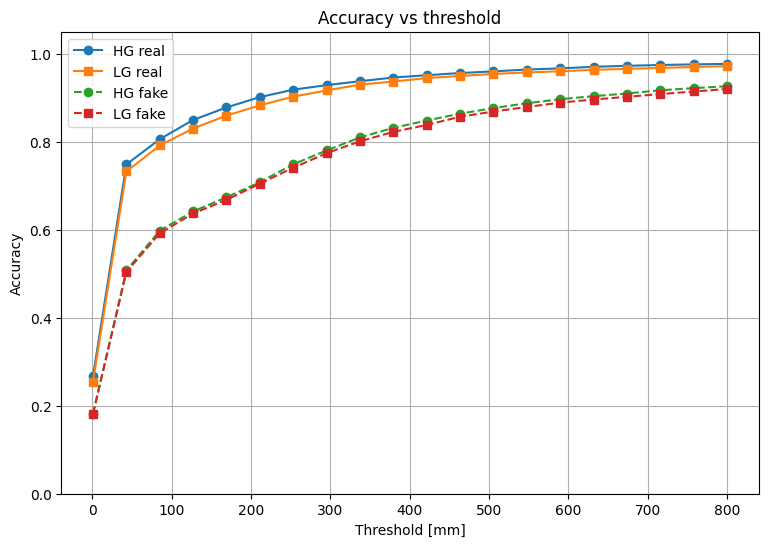

In [ ]:
plt.figure(figsize=(9,6))

plt.plot(threshold_values, acc_hg_real, "o-", label="HG real")
plt.plot(threshold_values, acc_lg_real, "s-", label="LG real")

plt.plot(threshold_values, acc_hg_fake, "o--", label="HG fake")
plt.plot(threshold_values, acc_lg_fake, "s--", label="LG fake")

plt.xlabel("Threshold [mm]")
plt.ylabel("Accuracy")
plt.title("Accuracy vs threshold")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()

plt.show()


In [55]:

def build_tagged_df1(df_dist, threshold, dist_col="d_weight"):
    """
    Assegna ogni retta al cluster più vicino e applica un threshold di distanza.
    Mantiene anche le colonne 'event', 'mcrun', 'revent' o 'fevent'.
    """
    tagged = []

    # controlla quale colonna usare per raggruppare
    if "revent" in df_dist.columns:
        group_col = "revent"
    elif "fevent" in df_dist.columns:
        group_col = "fevent"
    else:
        group_col = None

    for _, df_evt in (df_dist.groupby(group_col) if group_col else [(0, df_dist)]):
        clusters = df_evt["cluster"].unique()

        for idx, row in df_evt.iterrows():
            # distanza minima dal cluster
            cluster_distances = df_evt.groupby("cluster")[dist_col].apply(lambda x: np.mean(x))
            nearest_cluster = cluster_distances.idxmin()
            dmin = cluster_distances.min()

            tag = "this_event" if dmin <= threshold else "other_event"

            out = {
                "cluster": nearest_cluster,
                "tel": row["tel"],
                dist_col: row[dist_col],
                "tag": tag
            }

            # aggiungi le colonne per il confronto
            for col in ["event", "mcrun", "revent", "fevent"]:
                if col in row:
                    out[col] = row[col]

            tagged.append(out)

    return pd.DataFrame(tagged)

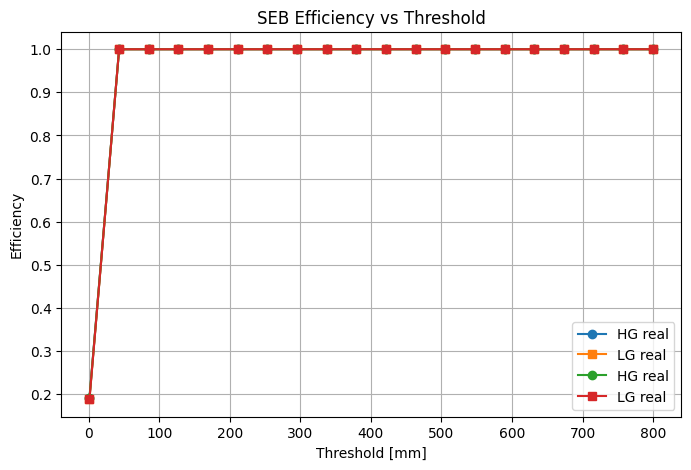

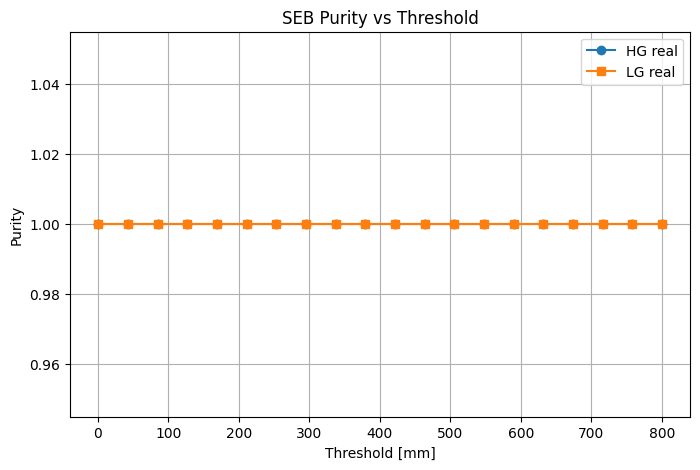

In [58]:
'''
threshold_values = np.linspace(1, 800, 20)

acc_hg_real = []
acc_lg_real = []
acc_hg_fake = []
acc_lg_fake = []

for thr in threshold_values:

    # ===== REAL EVENTS =====
    df_hg_tagged = build_tagged_df1(
        df_dist_hg, threshold=thr, dist_col="d_weight"
    )
    df_lg_tagged = build_tagged_df1(
        df_dist_lg, threshold=thr, dist_col="d_weight"
    )

    acc_hg_real.append(evaluate_simple_clustering(df_hg_tagged))
    acc_lg_real.append(evaluate_simple_clustering(df_lg_tagged))

    # ===== FAKE EVENTS =====
    df_hg_tagged_f = build_tagged_df1(
        df_dist_hg_f, threshold=thr, dist_col="d_mean_weighted"
    )
    df_lg_tagged_f = build_tagged_df1(
        df_dist_lg_f, threshold=thr, dist_col="d_mean_weighted"
    )

    acc_hg_fake.append(evaluate_simple_clustering(df_hg_tagged_f))
    acc_lg_fake.append(evaluate_simple_clustering(df_lg_tagged_f))
'''
threshold_values = np.linspace(1, 800, 20)

eff_hg_real = []
pur_hg_real = []
eff_lg_real = []
pur_lg_real = []


eff_hg_fake = []
pur_hg_fake = []
eff_lg_fake = []
pur_lg_fake = []

for thr in threshold_values:
    df_hg_tagged = build_tagged_df1(df_dist_hg, threshold=thr, dist_col="d_weight")
    df_lg_tagged = build_tagged_df1(df_dist_lg, threshold=thr, dist_col="d_weight")
    
    res_hg = evaluate_performance(df_hg_tagged, tag_col="tag", group_col="revent")
    res_lg = evaluate_performance(df_lg_tagged, tag_col="tag", group_col="revent")
    
    eff_hg_real.append(res_hg["efficiency"])
    pur_hg_real.append(res_hg["purity"])
    eff_lg_real.append(res_lg["efficiency"])
    pur_lg_real.append(res_lg["purity"])

    df_hg_tagged_f = build_tagged_df1(df_dist_hg, threshold=thr, dist_col="d_weight")
    df_lg_tagged_f = build_tagged_df1(df_dist_lg, threshold=thr, dist_col="d_weight")
    
    res_hg_f = evaluate_performance(df_hg_tagged_f, tag_col="tag", group_col="revent")
    res_lg_f = evaluate_performance(df_lg_tagged_f, tag_col="tag", group_col="revent")
    
    eff_hg_fake.append(res_hg_f["efficiency"])
    pur_hg_fake.append(res_hg_f["purity"])
    
    eff_lg_fake.append(res_lg_f["efficiency"])
    pur_lg_fake.append(res_lg_f["purity"])

# Plot efficienza
plt.figure(figsize=(8,5))
plt.plot(threshold_values, eff_hg_real, marker='o', label="HG real")
plt.plot(threshold_values, eff_lg_real, marker='s', label="LG real")
plt.plot(threshold_values, eff_hg_fake, marker='o', label="HG real")
plt.plot(threshold_values, eff_lg_fake, marker='s', label="LG real")

plt.xlabel("Threshold [mm]")
plt.ylabel("Efficiency")
plt.title("SEB Efficiency vs Threshold")
plt.grid(True)
plt.legend()
plt.show()

# Plot purezza
plt.figure(figsize=(8,5))
plt.plot(threshold_values, pur_hg_real, marker='o', label="HG real")
plt.plot(threshold_values, pur_lg_real, marker='s', label="LG real")
plt.xlabel("Threshold [mm]")
plt.ylabel("Purity")
plt.title("SEB Purity vs Threshold")
plt.grid(True)
plt.legend()
plt.show()


In [57]:
threshold_values = np.linspace(1, 800, 20)

eff_hg_real = []
pur_hg_real = []
eff_lg_real = []
pur_lg_real = []

for thr in threshold_values:
    df_hg_tagged = build_tagged_df1(df_dist_hg, threshold=thr, dist_col="d_weight")
    df_lg_tagged = build_tagged_df1(df_dist_lg, threshold=thr, dist_col="d_weight")
    
    res_hg = evaluate_performance(df_hg_tagged, tag_col="tag", group_col="revent")
    res_lg = evaluate_performance(df_lg_tagged, tag_col="tag", group_col="revent")
    
    eff_hg_real.append(res_hg["efficiency"])
    pur_hg_real.append(res_hg["purity"])
    
    eff_lg_real.append(res_lg["efficiency"])
    pur_lg_real.append(res_lg["purity"])

# Plot efficienza
plt.figure(figsize=(8,5))
plt.plot(threshold_values, eff_hg_real, marker='o', label="HG real")
plt.plot(threshold_values, eff_lg_real, marker='s', label="LG real")
plt.xlabel("Threshold [mm]")
plt.ylabel("Efficiency")
plt.title("SEB Efficiency vs Threshold")
plt.grid(True)
plt.legend()
plt.show()

# Plot purezza
plt.figure(figsize=(8,5))
plt.plot(threshold_values, pur_hg_real, marker='o', label="HG real")
plt.plot(threshold_values, pur_lg_real, marker='s', label="LG real")
plt.xlabel("Threshold [mm]")
plt.ylabel("Purity")
plt.title("SEB Purity vs Threshold")
plt.grid(True)
plt.legend()
plt.show()


KeyboardInterrupt: 

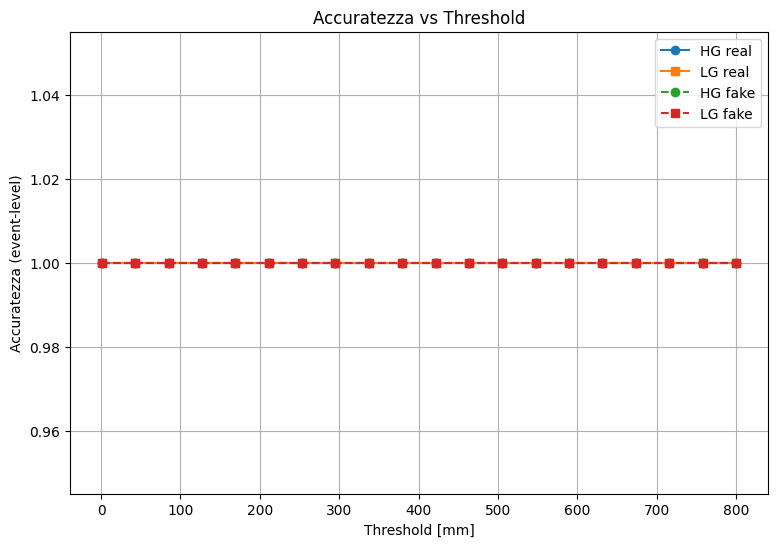

In [16]:
plt.figure(figsize=(9,6))

plt.plot(threshold_values, acc_hg_real,  marker='o', label="HG real")
plt.plot(threshold_values, acc_lg_real,  marker='s', label="LG real")

plt.plot(threshold_values, acc_hg_fake,  marker='o', linestyle='--', label="HG fake")
plt.plot(threshold_values, acc_lg_fake,  marker='s', linestyle='--', label="LG fake")

plt.xlabel("Threshold [mm]")
plt.ylabel("Accuratezza (event-level)")
plt.title("Accuratezza vs Threshold")
plt.grid(True)
plt.legend()
plt.show()


/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


=== Risultati clustering ===
Accuracy:  0.000
Precision: 0.000
Recall:    0.000
Matrice di confusione:
[[   0    0]
 [4024    0]]
=== Risultati clustering ===
Accuracy:  0.000
Precision: 0.000
Recall:    0.000
Matrice di confusione:
[[   0    0]
 [4065    0]]
=== Risultati clustering ===
Accuracy:  0.559
Precision: 1.000
Recall:    0.559
Matrice di confusione:
[[   0    0]
 [1774 2250]]
=== Risultati clustering ===
Accuracy:  0.541
Precision: 1.000
Recall:    0.541
Matrice di confusione:
[[   0    0]
 [1867 2198]]
=== Risultati clustering ===
Accuracy:  0.904
Precision: 1.000
Recall:    0.904
Matrice di confusione:
[[   0    0]
 [ 388 3636]]
=== Risultati clustering ===
Accuracy:  0.896
Precision: 1.000
Recall:    0.896
Matrice di confusione:
[[   0    0]
 [ 423 3642]]
=== Risultati clustering ===
Accuracy:  0.985
Precision: 1.000
Recall:    0.985
Matrice di confusione:
[[   0    0]
 [  60 3964]]
=== Risultati clustering ===
Accuracy:  0.985
Precision: 1.000
Recall:    0.985
Matrice di

/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


=== Risultati clustering ===
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
Matrice di confusione:
[[4024]]
=== Risultati clustering ===
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
Matrice di confusione:
[[4065]]


/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


...

=== Risultati clustering ===
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
Matrice di confusione:
[[4024]]
=== Risultati clustering ===
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
Matrice di confusione:
[[4065]]


/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


=== Risultati clustering ===
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
Matrice di confusione:
[[4024]]
=== Risultati clustering ===
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
Matrice di confusione:
[[4065]]


/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


=== Risultati clustering ===
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
Matrice di confusione:
[[4024]]
=== Risultati clustering ===
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
Matrice di confusione:
[[4065]]


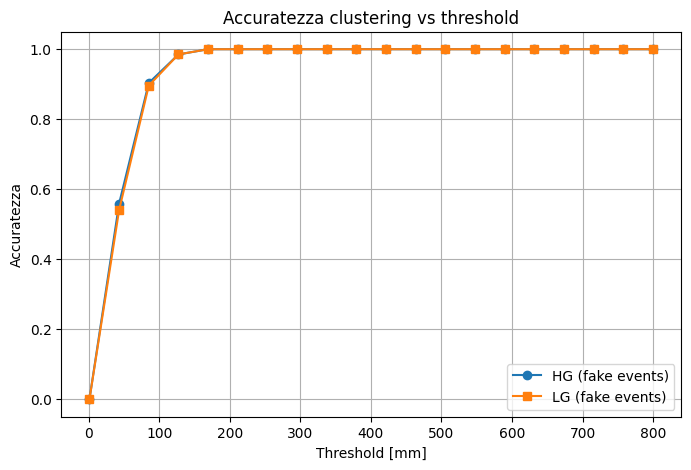

In [ ]:
threshold_values = np.linspace(1, 800, 20) 
acc_hg_fake = []
acc_lg_fake = []

for thr in threshold_values:
    # assegna ogni retta al cluster più vicino e calcola il tag
    df_hg_tagged_f = build_tagged_df1(df_dist_hg_f, thr, dist_col="d_mean_weighted")
    df_lg_tagged_f = build_tagged_df1(df_dist_lg_f, thr, dist_col="d_mean_weighted")

    # calcola accuratezza
    acc_hg_fake.append(evaluate_simple_clustering(df_hg_tagged_f)[0])
    acc_lg_fake.append(evaluate_simple_clustering(df_lg_tagged_f)[0])

# ================= PLOT =================
plt.figure(figsize=(8,5))
plt.plot(threshold_values, acc_hg_fake, marker='o', label="HG (fake events)")
plt.plot(threshold_values, acc_lg_fake, marker='s', label="LG (fake events)")

plt.xlabel("Threshold [mm]")
plt.ylabel("Accuratezza")
plt.title("Accuratezza clustering vs threshold")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
def build_tagged_df_threshold(df_dist, threshold, dist_col="d_mean_weighted"):
    """
    Assegna ogni retta al cluster più vicino (tra tutti i cluster del suo fevent)
    e applica un threshold di distanza.

    df_dist: DataFrame con colonne 'cluster', 'tel', dist_col, e 'fevent'
    threshold: distanza massima per considerare la retta parte del cluster
    dist_col: colonna con le distanze dai centroidi
    """
    tagged = []

    group_cols = ["fevent"] if "fevent" in df_dist.columns else ["event", "mcrun"]

    for _, df_evt in df_dist.groupby(group_cols):
        for tel, df_tel in df_evt.groupby("tel"):
            # cluster più vicino
            idx_min = df_tel[dist_col].idxmin()
            best_row = df_tel.loc[idx_min]

            tag = "this_event" if best_row[dist_col] <= threshold else "other_event"

            out = {
                "cluster": best_row["cluster"],
                "tel": tel,
                dist_col: best_row[dist_col],
                "tag": tag
            }

            for col in group_cols:
                out[col] = best_row[col]

            tagged.append(out)

    return pd.DataFrame(tagged)


=== Risultati clustering ===
Accuracy:  0.424
Precision: 1.000
Recall:    0.424
Matrice di confusione:
[[  0   0]
 [659 486]]
=== Risultati clustering ===
Accuracy:  0.431
Precision: 1.000
Recall:    0.431
Matrice di confusione:
[[  0   0]
 [651 494]]
=== Risultati clustering ===
Accuracy:  0.941
Precision: 1.000
Recall:    0.941
Matrice di confusione:
[[   0    0]
 [  67 1078]]
=== Risultati clustering ===
Accuracy:  0.946
Precision: 1.000
Recall:    0.946
Matrice di confusione:
[[   0    0]
 [  62 1083]]
=== Risultati clustering ===
Accuracy:  0.997
Precision: 1.000
Recall:    0.997
Matrice di confusione:
[[   0    0]
 [   4 1141]]
=== Risultati clustering ===
Accuracy:  0.997
Precision: 1.000
Recall:    0.997
Matrice di confusione:
[[   0    0]
 [   4 1141]]


/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


=== Risultati clustering ===
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
Matrice di confusione:
[[1145]]
=== Risultati clustering ===
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
Matrice di confusione:
[[1145]]


/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


=== Risultati clustering ===
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
Matrice di confusione:
[[1145]]
=== Risultati clustering ===
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
Matrice di confusione:
[[1145]]


...

/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


=== Risultati clustering ===
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
Matrice di confusione:
[[1145]]
=== Risultati clustering ===
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
Matrice di confusione:
[[1145]]


/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


=== Risultati clustering ===
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
Matrice di confusione:
[[1145]]
=== Risultati clustering ===
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
Matrice di confusione:
[[1145]]
=== Risultati clustering ===
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
Matrice di confusione:
[[1145]]
=== Risultati clustering ===
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
Matrice di confusione:
[[1145]]


/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


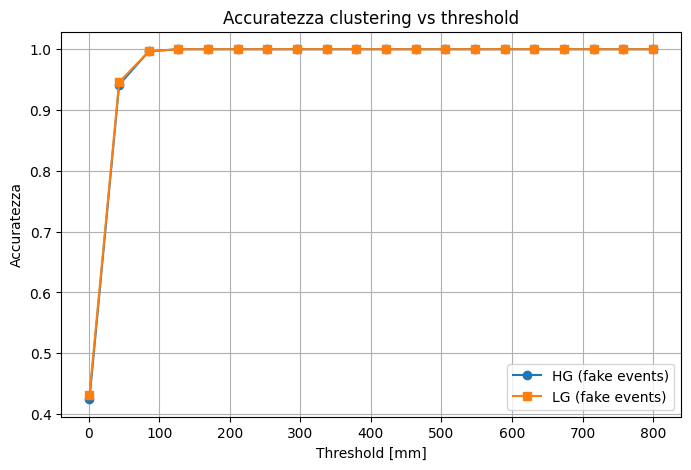

In [ ]:
threshold_values = np.linspace(1, 800, 20)
acc_hg_fake = []
acc_lg_fake = []

for thr in threshold_values:
    df_hg_tagged_f = build_tagged_df_threshold(df_dist_hg_f, thr, "d_mean_weighted")
    df_lg_tagged_f = build_tagged_df_threshold(df_dist_lg_f, thr, "d_mean_weighted")

    acc_hg_fake.append(evaluate_simple_clustering(df_hg_tagged_f)[0])
    acc_lg_fake.append(evaluate_simple_clustering(df_lg_tagged_f)[0])

plt.figure(figsize=(8,5))
plt.plot(threshold_values, acc_hg_fake, marker='o', label="HG (fake events)")
plt.plot(threshold_values, acc_lg_fake, marker='s', label="LG (fake events)")
plt.xlabel("Threshold [mm]")
plt.ylabel("Accuratezza")
plt.title("Accuratezza clustering vs threshold")
plt.grid(True)
plt.legend()
plt.show()
